<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/pca_kmeans_101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA + KMeans: Dimensionality Reduction

**Goal:**
* Show clustering WITHOUT PCA on high-dimensional data
* Show clustering WITH PCA
* Compare results clearly


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## Step 1: Generate High-Dimensional Data

In [ ]:
X, y_true = make_blobs(n_samples=50000, centers=4, n_features=100, random_state=42)
print("Shape of data:", X.shape)

Shape of data: (50000, 100)


## Step 2: Scale Data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 3: KMeans WITHOUT PCA

In [ ]:
kmeans_no_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_no_pca = kmeans_no_pca.fit_predict(X_scaled)

score_no_pca = silhouette_score(X_scaled, labels_no_pca)
print("Silhouette Score (No PCA):", score_no_pca)

Silhouette Score (No PCA): 0.791449596104388


## Step 4: Apply PCA

In [ ]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)

Original shape: (50000, 100)
Reduced shape: (50000, 4)
Explained variance ratio: [0.36182692 0.30793507 0.27795929 0.00435844]


## Step 5: KMeans WITH PCA

In [ ]:
kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca)

score_pca = silhouette_score(X_pca, labels_pca)
print("Silhouette Score (With PCA):", score_pca)

Silhouette Score (With PCA): 0.9370369653937577


## Step 6: Visualization (2D after PCA)

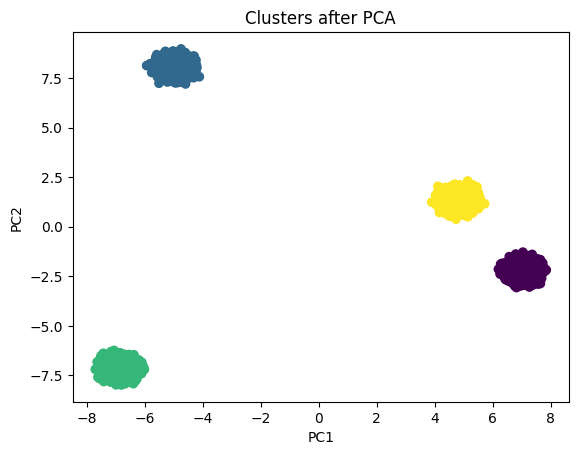

In [ ]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca)
plt.title("Clusters after PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Key Points

* High-dimensional data is harder to visualize and sometimes noisy
* PCA reduces dimensions while preserving maximum variance
* KMeans works better or similarly on reduced data
* PCA makes visualization possible